<a href="https://colab.research.google.com/github/venkatprasadh/ViolinPlots/blob/main/Violin_Plots_F1_JapaneseGP_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fastf1

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
%cd '/content/drive/MyDrive/Colab Notebooks/'

/content/drive/MyDrive/Colab Notebooks


In [ ]:
import fastf1 as ff1
from fastf1 import plotting
from fastf1 import utils
import fastf1.legacy
import fastf1 as ff1
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib import cm
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
import os

# Create the directory if it doesn't exist
if not os.path.exists('Cache'):
    os.makedirs('Cache')

ff1.Cache.enable_cache('Cache')

In [ ]:
ff1.Cache.enable_cache('Cache')
plotting.setup_mpl()

In [ ]:
year= 2026
gp = 3   #It corrrespond to United States, Circuit of the Americas, We have 3 GP in US (Miamia, Austin and Vegas)
event = 'Race'


In [ ]:
session_race = ff1.get_session(year, gp, event)
session_race.load()

core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.2]
INFO:fastf1.fastf1.core:Loading data for Japanese Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status

In [ ]:
point_finishers = session_race.drivers[:10]
print(point_finishers)


['12', '81', '16', '63', '1', '44', '10', '3', '30', '31']


In [ ]:
driver_laps = session_race.laps.pick_drivers(point_finishers).pick_quicklaps()
driver_laps = driver_laps.reset_index()

In [ ]:
finishing_order = [session_race.get_driver(i)["Abbreviation"] for i in point_finishers]
print(finishing_order)

['ANT', 'PIA', 'LEC', 'RUS', 'NOR', 'HAM', 'GAS', 'VER', 'LAW', 'OCO']


In [ ]:
# The modern fix:
driver_colors = {
    abv: fastf1.plotting.get_driver_color(abv, session=session_race)
    for abv in session_race.results['Abbreviation']
}

print(driver_colors)

req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info


{'ANT': '#27f4d2', 'PIA': '#ff8000', 'LEC': '#e80020', 'RUS': '#27f4d2', 'NOR': '#ff8000', 'HAM': '#e80020', 'GAS': '#ff87bc', 'VER': '#0600ef', 'LAW': '#fcd700', 'OCO': '#b6babd', 'HUL': '#ff2d00', 'HAD': '#0600ef', 'BOR': '#ff2d00', 'LIN': '#fcd700', 'SAI': '#00a0dd', 'COL': '#ff87bc', 'PER': '#444444', 'ALO': '#00665f', 'BOT': '#444444', 'ALB': '#00a0dd', 'STR': '#00665f', 'BEA': '#b6babd'}


<Axes: xlabel='Driver', ylabel='LapTime(s)'>

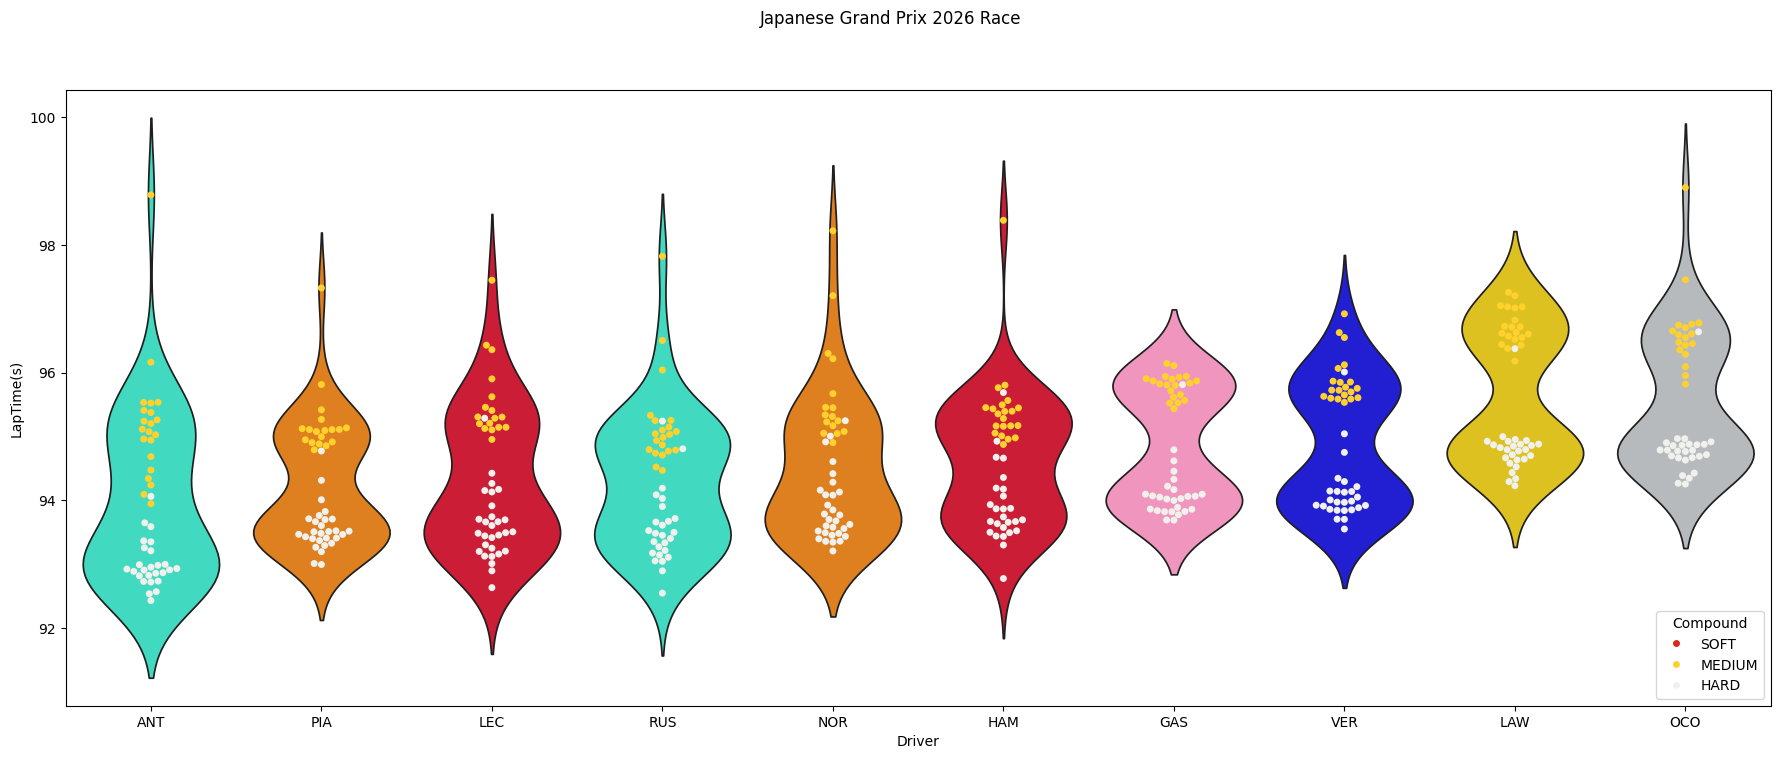

In [ ]:
# create the figure
fig, ax = plt.subplots(figsize=(22, 8))
title = f"{session_race.event['EventName']} {session_race.event.year} " + event
plt.suptitle(title)

# Convert timedelta to float
driver_laps["LapTime(s)"] = driver_laps["LapTime"].dt.total_seconds()

# Fix 1: Updated violinplot syntax to avoid FutureWarnings
sns.violinplot(data=driver_laps,
               x="Driver",
               y="LapTime(s)",
               hue="Driver",        # Assigning x to hue as requested by Seaborn
               legend=False,        # Hiding the redundant legend
               inner=None,
               density_norm="area", # 'scale' is now 'density_norm'
               order=finishing_order,
               palette=driver_colors
               )

# Fix 2: Updated Compound Colors lookup
sns.swarmplot(data=driver_laps,
              x="Driver",
              y="LapTime(s)",
              order=finishing_order,
              hue="Compound",
              # Use the new helper function for compound colors:
              palette={k: fastf1.plotting.get_compound_color(k, session=session_race)
                       for k in ["SOFT", "MEDIUM", "HARD"]},
              hue_order=["SOFT", "MEDIUM", "HARD"],
              linewidth=0,
              size=5,
              )